In [63]:
docs="""Artificial intelligence is one of the most exciting fields in computer science.
It is changing the way people interact with technology in their daily lives.
Machine learning allows computers to learn patterns from data.
It can make predictions without being explicitly programmed for every individual task.
Deep learning is a branch of machine learning.
It uses neural networks with multiple layers to solve complex problems.
Deep learning can be used for image classification and speech recognition.
It is also useful for natural language processing and recommendation systems.
Recurrent neural networks are designed to work with sequential data.
Traditional RNNs can have difficulty remembering information from long sequences.
This problem is known as the vanishing gradient problem.
Long Short Term Memory networks are commonly known as LSTMs.
LSTMs were introduced to overcome the limitations of traditional RNNs.
They use special memory cells and gates to control information.
The gates decide what information should be remembered or forgotten.
Because LSTMs can remember important information for a longer period of time.
They are useful for many natural language processing applications.
LSTMs can be used for text generation and language modeling.
They can also be used for sentiment analysis and machine translation.
Another important application is next word prediction.
In next word prediction the model receives a sequence of words as input.
The model learns the relationship between different words.
It then predicts which word is most likely to come next.
For example machine learning is a common phrase.
The model can learn that the next word may be powerful.
As the model receives more text during training it learns language patterns.
It gradually learns common sentence structures and word relationships.
This helps the model generate meaningful sequences of text.
An LSTM model can therefore be used to build a simple language model.
The language model can predict the next word based on previous words.
The more useful training data the model receives the better it can learn.
Good training data contains many different sentences and word combinations.
During training the input sentences are converted into numerical representations.
These numerical representations are given to the LSTM network.
The LSTM processes the sequence one word at a time.
It keeps important information in its memory.
Finally the output layer predicts the probability of possible next words.
The word with the highest probability can be selected as the prediction.
This process can be repeated to generate longer sentences.
Therefore LSTMs are useful for learning patterns in sequential text data."""

In [64]:
len(docs)

2697

In [65]:
import numpy as np 
import tensorflow 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense,Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [66]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts([docs])

In [67]:
tokenizer.word_index

{'the': 1,
 'can': 2,
 'it': 3,
 'to': 4,
 'for': 5,
 'word': 6,
 'model': 7,
 'is': 8,
 'be': 9,
 'of': 10,
 'and': 11,
 'learning': 12,
 'a': 13,
 'language': 14,
 'are': 15,
 'next': 16,
 'in': 17,
 'data': 18,
 'information': 19,
 'as': 20,
 'lstms': 21,
 'with': 22,
 'machine': 23,
 'used': 24,
 'useful': 25,
 'text': 26,
 'words': 27,
 'training': 28,
 'learn': 29,
 'patterns': 30,
 'networks': 31,
 'this': 32,
 'memory': 33,
 'they': 34,
 'important': 35,
 'prediction': 36,
 'receives': 37,
 'learns': 38,
 'lstm': 39,
 'sentences': 40,
 'one': 41,
 'most': 42,
 'from': 43,
 'deep': 44,
 'neural': 45,
 'also': 46,
 'natural': 47,
 'processing': 48,
 'sequential': 49,
 'traditional': 50,
 'rnns': 51,
 'long': 52,
 'sequences': 53,
 'problem': 54,
 'known': 55,
 'gates': 56,
 'longer': 57,
 'time': 58,
 'many': 59,
 'sequence': 60,
 'input': 61,
 'different': 62,
 'predicts': 63,
 'common': 64,
 'more': 65,
 'during': 66,
 'generate': 67,
 'therefore': 68,
 'numerical': 69,
 'repre

In [68]:
unique_word=tokenizer.word_counts
unique_word

OrderedDict([('artificial', 1),
             ('intelligence', 1),
             ('is', 8),
             ('one', 2),
             ('of', 7),
             ('the', 26),
             ('most', 2),
             ('exciting', 1),
             ('fields', 1),
             ('in', 5),
             ('computer', 1),
             ('science', 1),
             ('it', 9),
             ('changing', 1),
             ('way', 1),
             ('people', 1),
             ('interact', 1),
             ('with', 4),
             ('technology', 1),
             ('their', 1),
             ('daily', 1),
             ('lives', 1),
             ('machine', 4),
             ('learning', 6),
             ('allows', 1),
             ('computers', 1),
             ('to', 9),
             ('learn', 3),
             ('patterns', 3),
             ('from', 2),
             ('data', 5),
             ('can', 12),
             ('make', 1),
             ('predictions', 1),
             ('without', 1),
             ('being', 1),


### now we will make the sequnace 

In [69]:
total_word=len(tokenizer.word_index)+1
print("total_word is --->>",total_word)

total_word is --->> 191


In [70]:
input_sequnace=[]
for line in docs.split('\n'):
    # print(line)   
    tokanized_sentance=tokenizer.texts_to_sequences([line])[0]
    for i in range(1,len(tokanized_sentance)):
        input_sequnace.append(tokanized_sentance[:i+1])                                                

In [71]:
input_sequnace

[[72, 73],
 [72, 73, 8],
 [72, 73, 8, 41],
 [72, 73, 8, 41, 10],
 [72, 73, 8, 41, 10, 1],
 [72, 73, 8, 41, 10, 1, 42],
 [72, 73, 8, 41, 10, 1, 42, 74],
 [72, 73, 8, 41, 10, 1, 42, 74, 75],
 [72, 73, 8, 41, 10, 1, 42, 74, 75, 17],
 [72, 73, 8, 41, 10, 1, 42, 74, 75, 17, 76],
 [72, 73, 8, 41, 10, 1, 42, 74, 75, 17, 76, 77],
 [3, 8],
 [3, 8, 78],
 [3, 8, 78, 1],
 [3, 8, 78, 1, 79],
 [3, 8, 78, 1, 79, 80],
 [3, 8, 78, 1, 79, 80, 81],
 [3, 8, 78, 1, 79, 80, 81, 22],
 [3, 8, 78, 1, 79, 80, 81, 22, 82],
 [3, 8, 78, 1, 79, 80, 81, 22, 82, 17],
 [3, 8, 78, 1, 79, 80, 81, 22, 82, 17, 83],
 [3, 8, 78, 1, 79, 80, 81, 22, 82, 17, 83, 84],
 [3, 8, 78, 1, 79, 80, 81, 22, 82, 17, 83, 84, 85],
 [23, 12],
 [23, 12, 86],
 [23, 12, 86, 87],
 [23, 12, 86, 87, 4],
 [23, 12, 86, 87, 4, 29],
 [23, 12, 86, 87, 4, 29, 30],
 [23, 12, 86, 87, 4, 29, 30, 43],
 [23, 12, 86, 87, 4, 29, 30, 43, 18],
 [3, 2],
 [3, 2, 88],
 [3, 2, 88, 89],
 [3, 2, 88, 89, 90],
 [3, 2, 88, 89, 90, 91],
 [3, 2, 88, 89, 90, 91, 92],
 [3, 

In [72]:
max_len=max([len(x) for x in input_sequnace])

In [73]:
max_len

13

In [74]:
padd_input_sequnce=pad_sequences(input_sequnace,maxlen=max_len,padding="pre")

In [75]:
padd_input_sequnce

array([[ 0,  0,  0, ...,  0, 72, 73],
       [ 0,  0,  0, ..., 72, 73,  8],
       [ 0,  0,  0, ..., 73,  8, 41],
       ...,
       [ 0,  0,  0, ..., 30, 17, 49],
       [ 0,  0,  0, ..., 17, 49, 26],
       [ 0,  0, 68, ..., 49, 26, 18]], shape=(373, 13), dtype=int32)

In [76]:
X=padd_input_sequnce[:,:-1]

In [77]:
X

array([[ 0,  0,  0, ...,  0,  0, 72],
       [ 0,  0,  0, ...,  0, 72, 73],
       [ 0,  0,  0, ..., 72, 73,  8],
       ...,
       [ 0,  0,  0, ..., 12, 30, 17],
       [ 0,  0,  0, ..., 30, 17, 49],
       [ 0,  0, 68, ..., 17, 49, 26]], shape=(373, 12), dtype=int32)

In [78]:
Y=padd_input_sequnce[:,-1]

In [79]:
Y

array([ 73,   8,  41,  10,   1,  42,  74,  75,  17,  76,  77,   8,  78,
         1,  79,  80,  81,  22,  82,  17,  83,  84,  85,  12,  86,  87,
         4,  29,  30,  43,  18,   2,  88,  89,  90,  91,  92,  93,   5,
        94,  95,  96,  12,   8,  13,  97,  10,  23,  12,  98,  45,  31,
        22,  99, 100,   4, 101, 102, 103,  12,   2,   9,  24,   5, 104,
       105,  11, 106, 107,   8,  46,  25,   5,  47,  14,  48,  11, 108,
       109,  45,  31,  15, 111,   4, 112,  22,  49,  18,  51,   2, 113,
       114, 115,  19,  43,  52,  53,  54,   8,  55,  20,   1, 116, 117,
        54, 118, 119,  33,  31,  15, 120,  55,  20,  21, 121, 122,   4,
       123,   1, 124,  10,  50,  51, 125, 126,  33, 127,  11,  56,   4,
       128,  19,  56, 129, 130,  19, 131,   9, 132, 133, 134,  21,   2,
       136,  35,  19,   5,  13,  57, 137,  10,  58,  15,  25,   5,  59,
        47,  14,  48, 138,   2,   9,  24,   5,  26, 139,  11,  14, 140,
         2,  46,   9,  24,   5, 141, 142,  11,  23, 143,  35, 14

### convrt the Y into the onr hot encoding 


In [80]:
Y=to_categorical(Y,num_classes=total_word)

In [81]:
Y.shape

(373, 191)

In [82]:
### now make the LSTM model 


In [83]:
model=Sequential()
model.add(Input(shape=(12,)))

In [84]:
model.add(Embedding(191,77)) ### iska matalb hain keh har waord ko 77 dimvectot main convrt karo aur input main 12 dim ka seqce hoga 

In [85]:
model.add(LSTM(150))

In [86]:
model.add(Dense(total_word,activation='softmax'))

In [87]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 12, 77)         │        14,707 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 150)            │       136,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 191)            │        28,841 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,348 (704.48 KB)

 Trainable params: 180,348 (704.48 KB)

 Non-trainable params: 0 (0.00 B)

In [89]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[]


In [97]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [98]:
history=model.fit(X, Y, epochs=100)

Epoch 1/100


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9464 - loss: 0.1366
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9357 - loss: 0.1457
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9330 - loss: 0.1520
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9410 - loss: 0.1342
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9437 - loss: 0.1198
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9464 - loss: 0.1184
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9464 - loss: 0.1136
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9491 - loss: 0.1083
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9464 - loss: 0.1076
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9491 - loss: 0.1069
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9437 - loss: 0.1107
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy:

In [99]:
import matplotlib.pyplot as plt

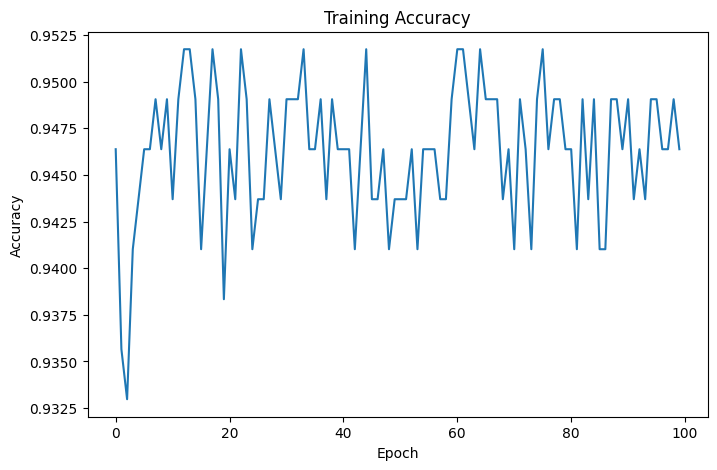

In [100]:

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()